# PhasorFlow — Neural Binding & Phase Synchronization

## From Coupled Oscillators to Perception

This notebook explores **neural binding** — the brain's mechanism for unifying distributed signals into coherent percepts. In phasor computing, binding means **phase synchronization**: when oscillators lock phases, they're "bound" into a single representation.

| # | Example | Gates/Modules Used | Concept |
|---|---------|-------------------|---------|
| 1 | LIP-Layer Phase Sync | LIPLayer | Basic 2-neuron binding |
| 2 | Kuramoto Consensus | Kuramoto gate (×N) | N-oscillator synchronization |
| 3 | Hierarchical Binding | Shift, Mix, Kuramoto, Normalize | Multi-level feature binding |
| 4 | Competing Populations | Kuramoto, Threshold | Winner-take-all competition |
| 5 | Temporal Sequence Binding | Shifts, AsymmetricCouple | Directional sequence memory |

In [1]:
import sys, os, shutil
parent = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', '..'))
if parent not in sys.path:
    sys.path.insert(0, parent)
for root, dirs, _ in os.walk(os.path.join(parent, 'PhasorFlow')):
    for d in dirs:
        if d == '__pycache__':
            shutil.rmtree(os.path.join(root, d), ignore_errors=True)
for key in list(sys.modules.keys()):
    if 'phasorflow' in key.lower():
        del sys.modules[key]

import phasorflow as pf
from phasorflow import PhasorCircuit
from phasorflow.engine.analytic import AnalyticEngine
from phasorflow.gates import *
from phasorflow.neuromorphic.lip_layer import LIPLayer
from phasorflow.neuromorphic.associative_memory import PhasorFlowMemory
import torch
import math
import numpy as np
import matplotlib.pyplot as plt

torch.set_printoptions(precision=4, sci_mode=False)
engine = AnalyticEngine()

def print_circuit_stats(circ):
    print(f"  Circuit:  {circ.name}")
    print(f"  Threads:  {circ.num_threads}, Gates: {circ.gate_count}, Depth: {circ.depth}")

def print_results(result):
    print(f"  Phases:     {result['phases']}")
    print(f"  Amplitudes: {result['amplitudes']}")

print(f"phasorflow v{pf.__version__} loaded")

phasorflow v0.2.0 loaded


---
## 1. LIP-Layer Phase Synchronization — Basic Neural Binding

Two sensory "neurons" start out of phase. The LIP (Lateral Inhibition/Phase) layer uses coupling weights to pull them into a unified rhythm — demonstrating how the brain binds visual and auditory signals.

**Module:** `LIPLayer`

  1. LIP-Layer: Neural Binding via Phase Synchronization


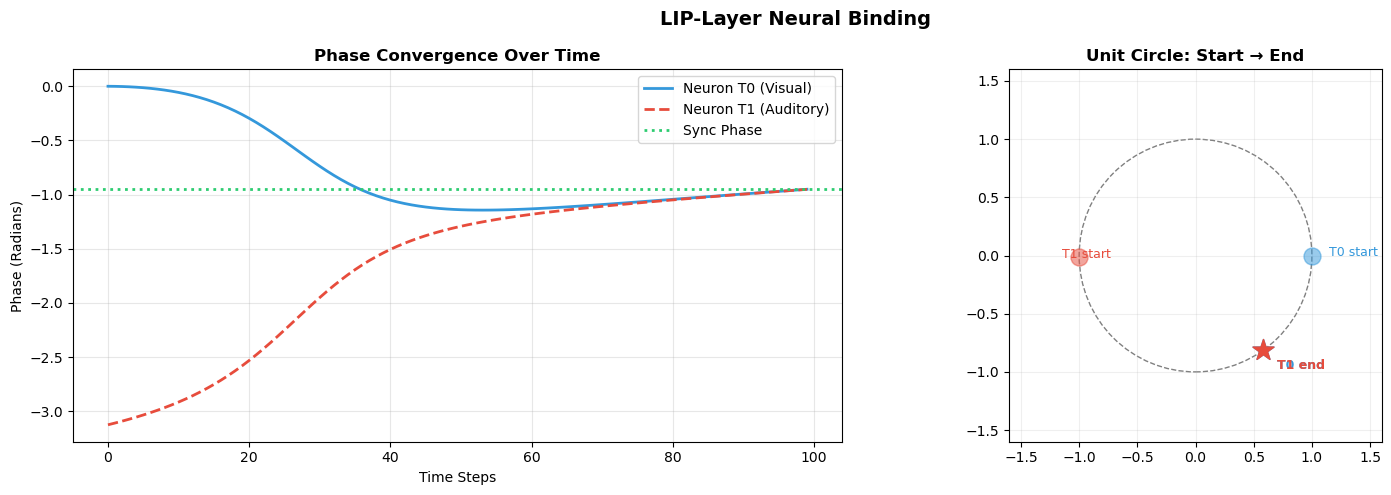


  Phase difference: 0.0007 rad
  Status: ✓ BOUND (synchronized)


In [2]:
print("=" * 60)
print("  1. LIP-Layer: Neural Binding via Phase Synchronization")
print("=" * 60)

n_threads = 2

# Initialize with large phase difference (T0 at 0, T1 at PI)
init_phases = torch.tensor([0.0, math.pi], dtype=torch.float32)
state = torch.exp(1j * init_phases)

# Strong coupling between the two neurons
lip = LIPLayer(num_threads=n_threads, leak_rate=0.05)
lip.weights = torch.tensor([[0.0, 0.5],
                            [0.5, 0.0]], dtype=torch.float32)

dt = 0.1
steps = 100
history_t0, history_t1 = [], []

for _ in range(steps):
    external_in = torch.zeros(n_threads, dtype=torch.float32)
    state = lip.update(state, external_in, dt=dt)
    angles = torch.angle(state)
    history_t0.append(angles[0].item())
    history_t1.append(angles[1].item())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(history_t0, label='Neuron T0 (Visual)', color='#3498db', lw=2)
ax.plot(history_t1, label='Neuron T1 (Auditory)', color='#e74c3c', lw=2, linestyle='--')
final_mean = (history_t0[-1] + history_t1[-1]) / 2.0
ax.axhline(y=final_mean, color='#2ecc71', linestyle=':', lw=2, label='Sync Phase')
ax.set_title('Phase Convergence Over Time', fontweight='bold')
ax.set_xlabel('Time Steps'); ax.set_ylabel('Phase (Radians)')
ax.legend(); ax.grid(True, alpha=0.3)

# Unit circle visualization
ax = axes[1]
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--')
ax.add_patch(circle)
for i, (h, color, label) in enumerate([(history_t0, '#3498db', 'T0'), (history_t1, '#e74c3c', 'T1')]):
    # Start
    ax.scatter(math.cos(h[0]), math.sin(h[0]), s=150, color=color, marker='o', zorder=3, alpha=0.5)
    # End
    ax.scatter(math.cos(h[-1]), math.sin(h[-1]), s=250, color=color, marker='*', zorder=4)
    ax.annotate(f'{label} start', xy=(math.cos(h[0])*1.15, math.sin(h[0])*1.15), fontsize=9, color=color)
    ax.annotate(f'{label} end', xy=(math.cos(h[-1])*1.2, math.sin(h[-1])*1.2), fontsize=9, color=color, fontweight='bold')
ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6); ax.set_aspect('equal')
ax.set_title('Unit Circle: Start → End', fontweight='bold')
ax.grid(True, alpha=0.2)

plt.suptitle('LIP-Layer Neural Binding', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

final_diff = abs(history_t0[-1] - history_t1[-1])
print(f"\n  Phase difference: {final_diff:.4f} rad")
print(f"  Status: {'✓ BOUND (synchronized)' if final_diff < 0.1 else '✗ Not synchronized'}")

---
## 2. Kuramoto Consensus — N-Oscillator Synchronization

The **Kuramoto model** is the gold standard for studying synchronization in coupled oscillators. Here, N neurons with random initial phases synchronize through all-to-all coupling.

**Gates:** `shift` → `kuramoto` (×iterations)

**Key insight:** Above a critical coupling strength $K_c$, the system spontaneously synchronizes — an emergent phase transition.

  2. Kuramoto: N-Oscillator Consensus


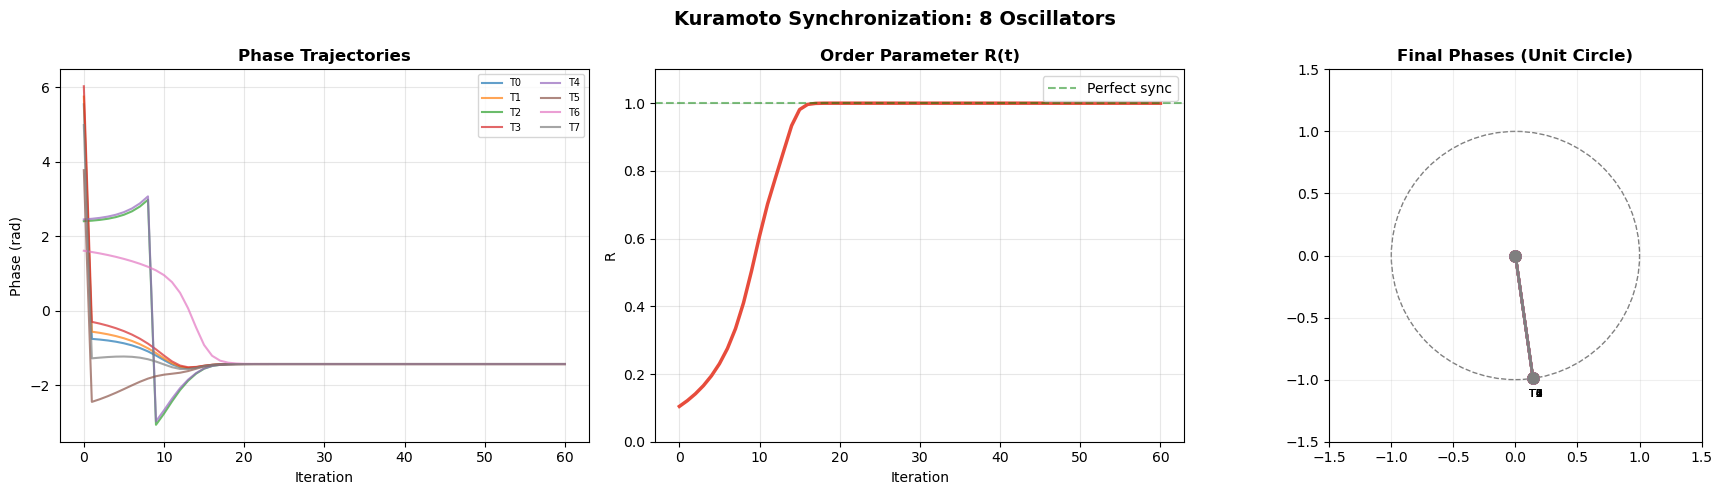


  Initial R: 0.1044
  Final   R: 1.0000
  Phase spread: 0.0000 rad


In [3]:
print("=" * 60)
print("  2. Kuramoto: N-Oscillator Consensus")
print("=" * 60)

N = 8
n_iter = 60

# Random initial phases
torch.manual_seed(42)
init_phases = torch.rand(N) * 2 * math.pi

# All-to-all coupling matrix
W = torch.ones(N, N, dtype=torch.float32)
W.fill_diagonal_(0)

# Track phase evolution
phase_history = [init_phases.numpy().copy()]
state = torch.exp(1j * init_phases)

for step in range(n_iter):
    circ = PhasorCircuit(N, name=f"Kuramoto_{step}")
    circ.kuramoto(W, dt=0.05, coupling_k=1.5)
    result = engine.run(circ, initial_state=state)
    state = result['state_vector']
    phases = torch.angle(state)
    phase_history.append(phases.detach().numpy().copy())

phase_arr = np.array(phase_history)

# Compute order parameter R(t) = |1/N * sum(e^{i*theta})|
order_param = []
for t in range(len(phase_history)):
    z = np.exp(1j * phase_arr[t])
    R = np.abs(np.mean(z))
    order_param.append(R)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Phase trajectories
ax = axes[0]
for i in range(N):
    ax.plot(phase_arr[:, i], label=f'T{i}', alpha=0.7, lw=1.5)
ax.set_title('Phase Trajectories', fontweight='bold')
ax.set_xlabel('Iteration'); ax.set_ylabel('Phase (rad)')
ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)

# Order parameter
ax = axes[1]
ax.plot(order_param, color='#e74c3c', lw=2.5)
ax.set_title('Order Parameter R(t)', fontweight='bold')
ax.set_xlabel('Iteration'); ax.set_ylabel('R')
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='green', linestyle='--', alpha=0.5, label='Perfect sync')
ax.legend(); ax.grid(True, alpha=0.3)

# Final state on unit circle
ax = axes[2]
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--')
ax.add_patch(circle)
final = phase_arr[-1]
for i, p in enumerate(final):
    ax.plot([0, math.cos(p)], [0, math.sin(p)], 'o-', color=plt.cm.tab10(i), lw=2, ms=8)
    ax.text(math.cos(p)*1.15, math.sin(p)*1.15, f'T{i}', fontsize=8, ha='center')
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect('equal')
ax.set_title('Final Phases (Unit Circle)', fontweight='bold')
ax.grid(True, alpha=0.2)

plt.suptitle(f'Kuramoto Synchronization: {N} Oscillators', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print(f"\n  Initial R: {order_param[0]:.4f}")
print(f"  Final   R: {order_param[-1]:.4f}")
print(f"  Phase spread: {np.ptp(final):.4f} rad")

---
## 3. Hierarchical Binding — Multi-Level Feature Fusion

Real neural systems bind features **hierarchically**: low-level features (edges) synchronize first, then mid-level features (shapes), then high-level concepts (objects).

**Gates:** `encode_phases` → `mix` (local binding) → `kuramoto` (global binding) → `normalize`

This circuit creates a 3-layer hierarchy: local features → grouped features → global percept.

  3. Hierarchical Binding: Multi-Level Feature Fusion
  Circuit:  HierarchicalBinding
  Threads:  8, Gates: 28, Depth: 4


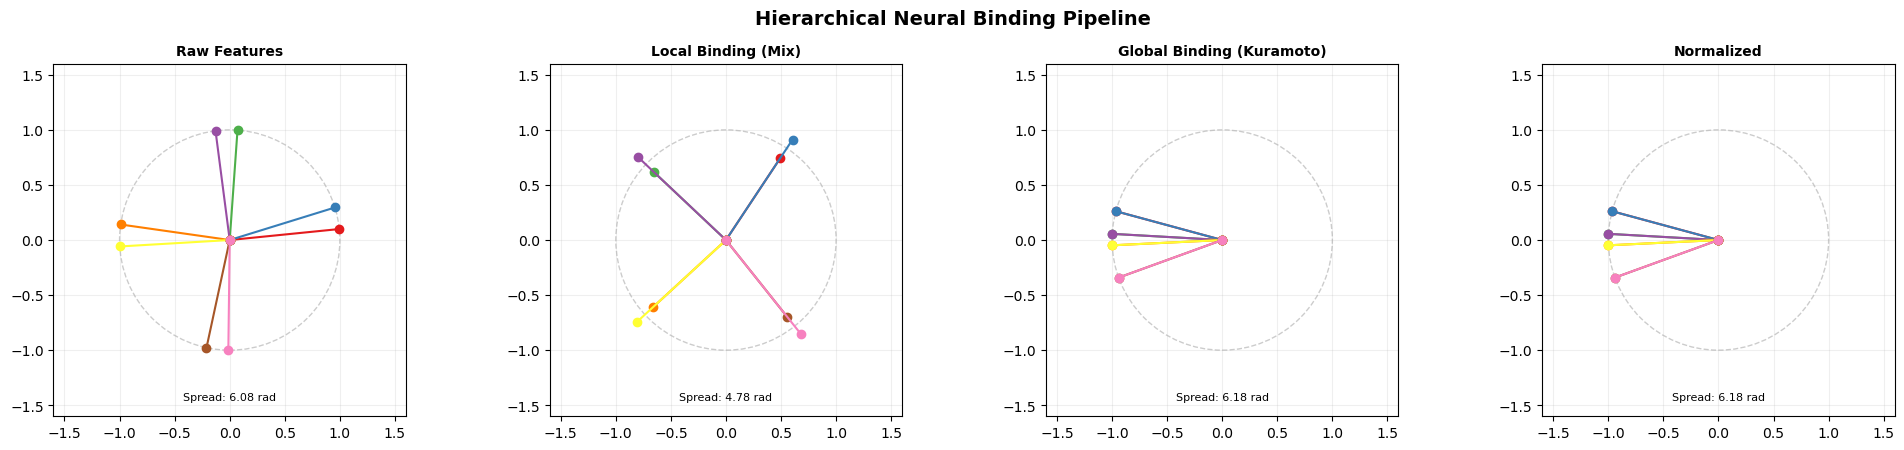

In [4]:
print("=" * 60)
print("  3. Hierarchical Binding: Multi-Level Feature Fusion")
print("=" * 60)

N = 8  # 8 features, grouped into 4 pairs

circ = PhasorCircuit(N, name="HierarchicalBinding")

# Layer 1: Encode raw features (diverse phases)
features = [0.1, 0.3, 1.5, 1.7, 3.0, 3.2, 4.5, 4.7]
for i, f in enumerate(features):
    circ.shift(i, f)
circ.barrier()
circ.measure("raw_features")

# Layer 2: LOCAL binding — mix adjacent pairs
circ.mix(0, 1)  # Pair [0,1]
circ.mix(2, 3)  # Pair [2,3]
circ.mix(4, 5)  # Pair [4,5]
circ.mix(6, 7)  # Pair [6,7]
circ.barrier()
circ.measure("local_bound")

# Layer 3: GLOBAL binding via Kuramoto
W = torch.ones(N, N, dtype=torch.float32)
W.fill_diagonal_(0)
for _ in range(15):
    circ.kuramoto(W, dt=0.05, coupling_k=1.0)
circ.barrier()
circ.measure("global_bound")

# Layer 4: Normalize to unit circle
circ.normalize()
circ.measure("final")

print_circuit_stats(circ)
result = engine.run(circ)

# Visualize 4 stages
stages = ['raw_features', 'local_bound', 'global_bound', 'final']
titles = ['Raw Features', 'Local Binding (Mix)', 'Global Binding (Kuramoto)', 'Normalized']
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, stage, title in zip(axes, stages, titles):
    snap = result['measurements'][stage]
    if isinstance(snap, dict):
        phases = snap['phases'].detach().numpy()
        amps = snap['amplitudes'].detach().numpy()
        circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--', alpha=0.4)
        ax.add_patch(circle)
        for i in range(N):
            r = min(amps[i], 1.5)
            ax.plot([0, r*math.cos(phases[i])], [0, r*math.sin(phases[i])],
                    'o-', color=plt.cm.Set1(i/N), lw=1.5, ms=6)
        ax.set_xlim(-1.6, 1.6); ax.set_ylim(-1.6, 1.6); ax.set_aspect('equal')
        ax.set_title(title, fontweight='bold', fontsize=10)
        ax.grid(True, alpha=0.2)
        spread = np.ptp(phases) if np.any(amps > 0.01) else 0
        ax.text(0, -1.45, f'Spread: {spread:.2f} rad', ha='center', fontsize=8)

plt.suptitle('Hierarchical Neural Binding Pipeline', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Competing Populations — Winner-Take-All via Ising + Threshold

In the brain, populations of neurons compete for dominance. Here, two groups start with different initial phases. The Ising gate drives binary partition, and Threshold selects the winning group.

**Gates:** `shift` → `ising` (×iterations) → `saturate` → `threshold`

**Application:** Binocular rivalry, attention selection.

  4. Competing Populations: Winner-Take-All
  Circuit:  CompetingPopulations
  Threads:  6, Gates: 48, Depth: 4


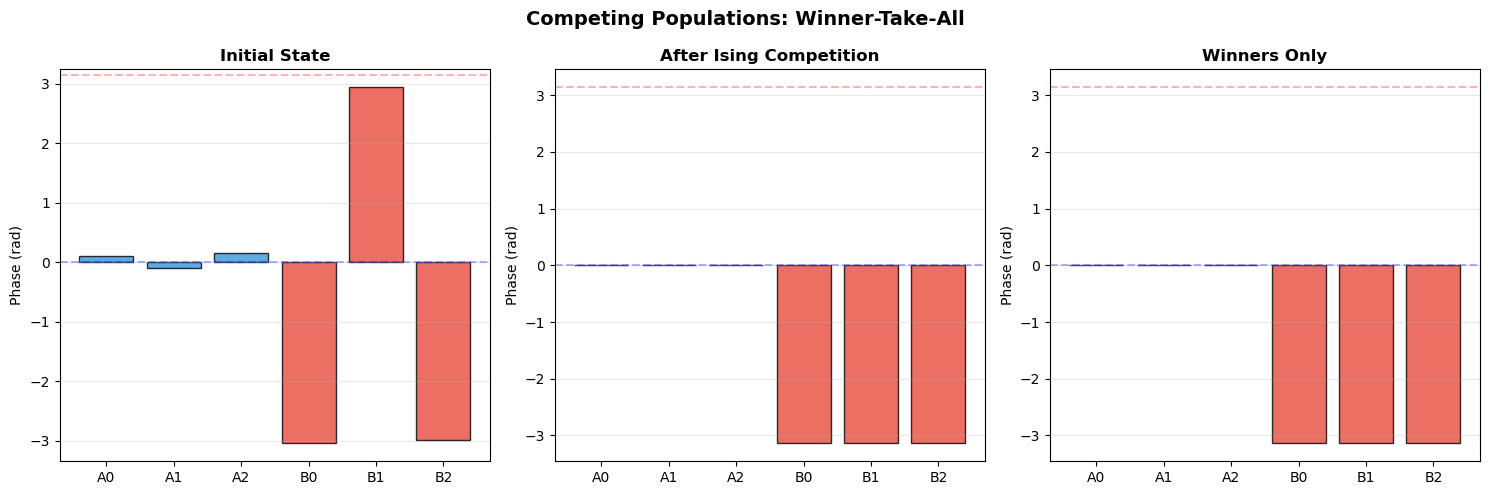

In [5]:
print("=" * 60)
print("  4. Competing Populations: Winner-Take-All")
print("=" * 60)

N = 6
circ = PhasorCircuit(N, name="CompetingPopulations")

# Two populations:
# Group A (threads 0,1,2): near phase 0
# Group B (threads 3,4,5): near phase π
group_a = [0.1, -0.1, 0.15]
group_b = [math.pi + 0.1, math.pi - 0.2, math.pi + 0.15]
for i, p in enumerate(group_a + group_b):
    circ.shift(i, p)
circ.barrier()
circ.measure("initial")

# Cross-group inhibition (anti-coupling)
A = torch.zeros(N, N, dtype=torch.float32)
# Within-group: excitatory
for i in range(3):
    for j in range(3):
        if i != j:
            A[i, j] = 0.5  # Group A internal
            A[i+3, j+3] = 0.5  # Group B internal
# Cross-group: inhibitory
for i in range(3):
    for j in range(3):
        A[i, j+3] = -0.3
        A[i+3, j] = -0.3

for _ in range(40):
    circ.ising(A, dt=0.05, coupling_k=1.0)
circ.barrier()
circ.saturate(levels=2)  # Snap to 0 or π
circ.barrier()
circ.measure("competing")

# Threshold to select dominant group
circ.threshold(threshold=0.5)
circ.measure("winners")

print_circuit_stats(circ)
result = engine.run(circ)

stages = ['initial', 'competing', 'winners']
titles = ['Initial State', 'After Ising Competition', 'Winners Only']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, stage, title in zip(axes, stages, titles):
    snap = result['measurements'][stage]
    if isinstance(snap, dict):
        phases = snap['phases'].detach().numpy()
        amps = snap['amplitudes'].detach().numpy()
        colors = ['#3498db' if i < 3 else '#e74c3c' for i in range(N)]
        ax.bar(range(N), phases, color=colors, edgecolor='black', alpha=0.8)
        ax.set_xticks(range(N))
        ax.set_xticklabels([f'A{i}' if i < 3 else f'B{i-3}' for i in range(N)])
        ax.set_ylabel('Phase (rad)')
        ax.set_title(title, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        ax.axhline(y=0, color='blue', linestyle='--', alpha=0.3)
        ax.axhline(y=math.pi, color='red', linestyle='--', alpha=0.3)

plt.suptitle('Competing Populations: Winner-Take-All', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Temporal Sequence Binding — Directional Phase Chains

The brain encodes sequences (A→B→C) using **asymmetric phase coupling**: each element's phase influences the next but not the reverse. The AsymmetricCouple gate creates directed phase chains.

**Gates:** `encode_phases` → `asymmetric_couple` (×iterations) → `normalize`

**Application:** Motor sequences, language processing, working memory.

  5. Temporal Sequence Binding via Asymmetric Coupling
  Circuit:  SequenceBinding
  Threads:  5, Gates: 26, Depth: 3


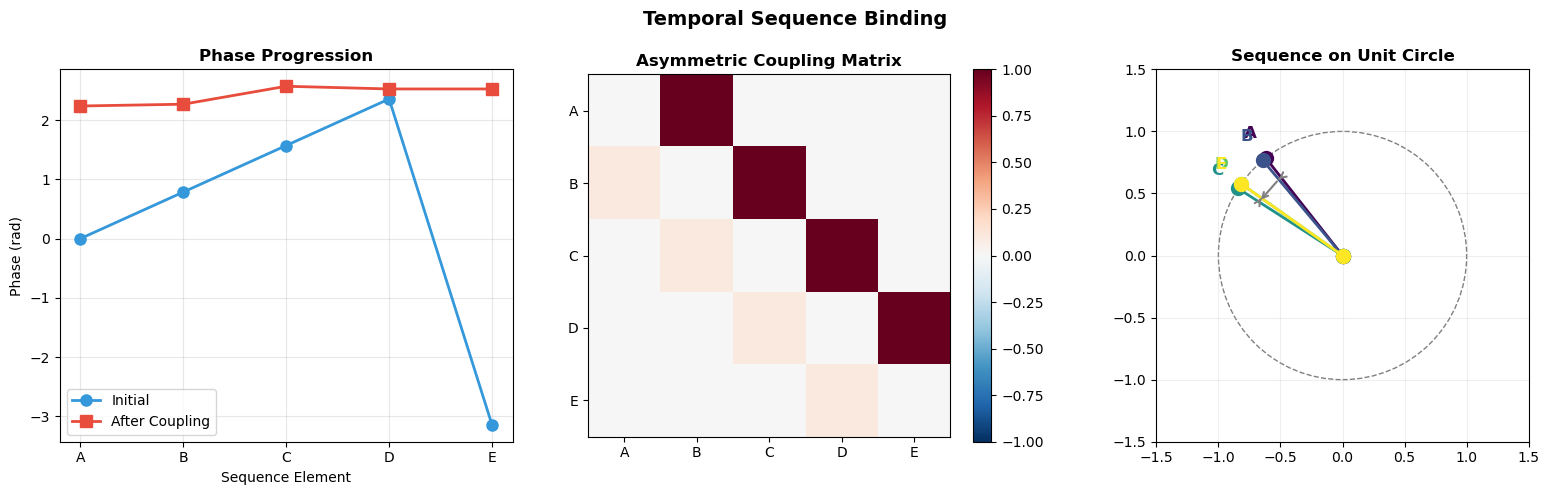

In [6]:
print("=" * 60)
print("  5. Temporal Sequence Binding via Asymmetric Coupling")
print("=" * 60)

N = 5  # Sequence length: A → B → C → D → E

# Encode sequence elements as distinct phases
seq_phases = [0.0, math.pi/4, math.pi/2, 3*math.pi/4, math.pi]

circ = PhasorCircuit(N, name="SequenceBinding")
for i, p in enumerate(seq_phases):
    circ.shift(i, p)
circ.barrier()
circ.measure("initial")

# Asymmetric coupling: forward direction only (i → i+1)
D = torch.zeros(N, N, dtype=torch.float32)
for i in range(N - 1):
    D[i, i+1] = 1.0  # Forward coupling
    D[i+1, i] = 0.1  # Weak backward leakage

for _ in range(20):
    circ.asymmetric_couple(D, dt=0.05)
circ.barrier()
circ.normalize()
circ.measure("coupled")

print_circuit_stats(circ)
result = engine.run(circ)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Phase progression
ax = axes[0]
init_snap = result['measurements']['initial']
final_snap = result['measurements']['coupled']
if isinstance(init_snap, dict) and isinstance(final_snap, dict):
    init_p = init_snap['phases'].detach().numpy()
    final_p = final_snap['phases'].detach().numpy()
    x = range(N)
    ax.plot(x, init_p, 'o-', color='#3498db', lw=2, ms=8, label='Initial')
    ax.plot(x, final_p, 's-', color='#e74c3c', lw=2, ms=8, label='After Coupling')
    ax.set_xticks(x)
    ax.set_xticklabels(['A', 'B', 'C', 'D', 'E'])
    ax.set_ylabel('Phase (rad)'); ax.set_xlabel('Sequence Element')
    ax.set_title('Phase Progression', fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)

# Coupling matrix heatmap
ax = axes[1]
im = ax.imshow(D.numpy(), cmap='RdBu_r', interpolation='nearest', vmin=-1, vmax=1)
ax.set_title('Asymmetric Coupling Matrix', fontweight='bold')
ax.set_xticks(range(N)); ax.set_yticks(range(N))
ax.set_xticklabels(['A', 'B', 'C', 'D', 'E'])
ax.set_yticklabels(['A', 'B', 'C', 'D', 'E'])
plt.colorbar(im, ax=ax)

# Unit circle showing directional flow
ax = axes[2]
circle = plt.Circle((0, 0), 1, fill=False, color='gray', linestyle='--')
ax.add_patch(circle)
if isinstance(final_snap, dict):
    fp = final_snap['phases'].detach().numpy()
    labels = ['A', 'B', 'C', 'D', 'E']
    colors = plt.cm.viridis(np.linspace(0, 1, N))
    for i in range(N):
        x_pos, y_pos = math.cos(fp[i]), math.sin(fp[i])
        ax.plot([0, x_pos], [0, y_pos], 'o-', color=colors[i], lw=2, ms=10)
        ax.text(x_pos*1.2, y_pos*1.2, labels[i], ha='center', fontsize=12,
                fontweight='bold', color=colors[i])
        if i < N - 1:
            x2, y2 = math.cos(fp[i+1]), math.sin(fp[i+1])
            ax.annotate('', xy=(x2*0.8, y2*0.8), xytext=(x_pos*0.8, y_pos*0.8),
                        arrowprops=dict(arrowstyle='->', lw=1.5, color='gray'))
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5); ax.set_aspect('equal')
ax.set_title('Sequence on Unit Circle', fontweight='bold')
ax.grid(True, alpha=0.2)

plt.suptitle('Temporal Sequence Binding', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## Summary

| Example | Mechanism | Key Result |
|---------|-----------|-----------|
| LIP-Layer Sync | Lateral coupling | 2 neurons lock phases |
| Kuramoto Consensus | All-to-all Kuramoto | N oscillators converge (order parameter → 1) |
| Hierarchical Binding | Mix (local) + Kuramoto (global) | Multi-scale feature unification |
| Competing Populations | Ising + Threshold | Winner-take-all selection |
| Temporal Sequence | Asymmetric coupling | Directed phase chains A→B→C |

> **Key insight:** Phase synchronization is the universal binding mechanism — from 2-neuron pairs to hierarchical multi-scale networks. PhasorFlow's gates (Kuramoto, Ising, AsymmetricCouple, Mix, Threshold) provide a complete toolkit for modeling these phenomena.